In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, pathlib

# adjust this to your repo root if different
repo_root = pathlib.Path.cwd()

# If running from the playground directory, move up one level to the repo root
if repo_root.name == 'playground':
    repo_root = repo_root.parent

sys.path.insert(0, str(repo_root))
print('Inserted repo root into sys.path:', repo_root)

Inserted repo root into sys.path: C:\Users\f.spreemann\qecsim-work


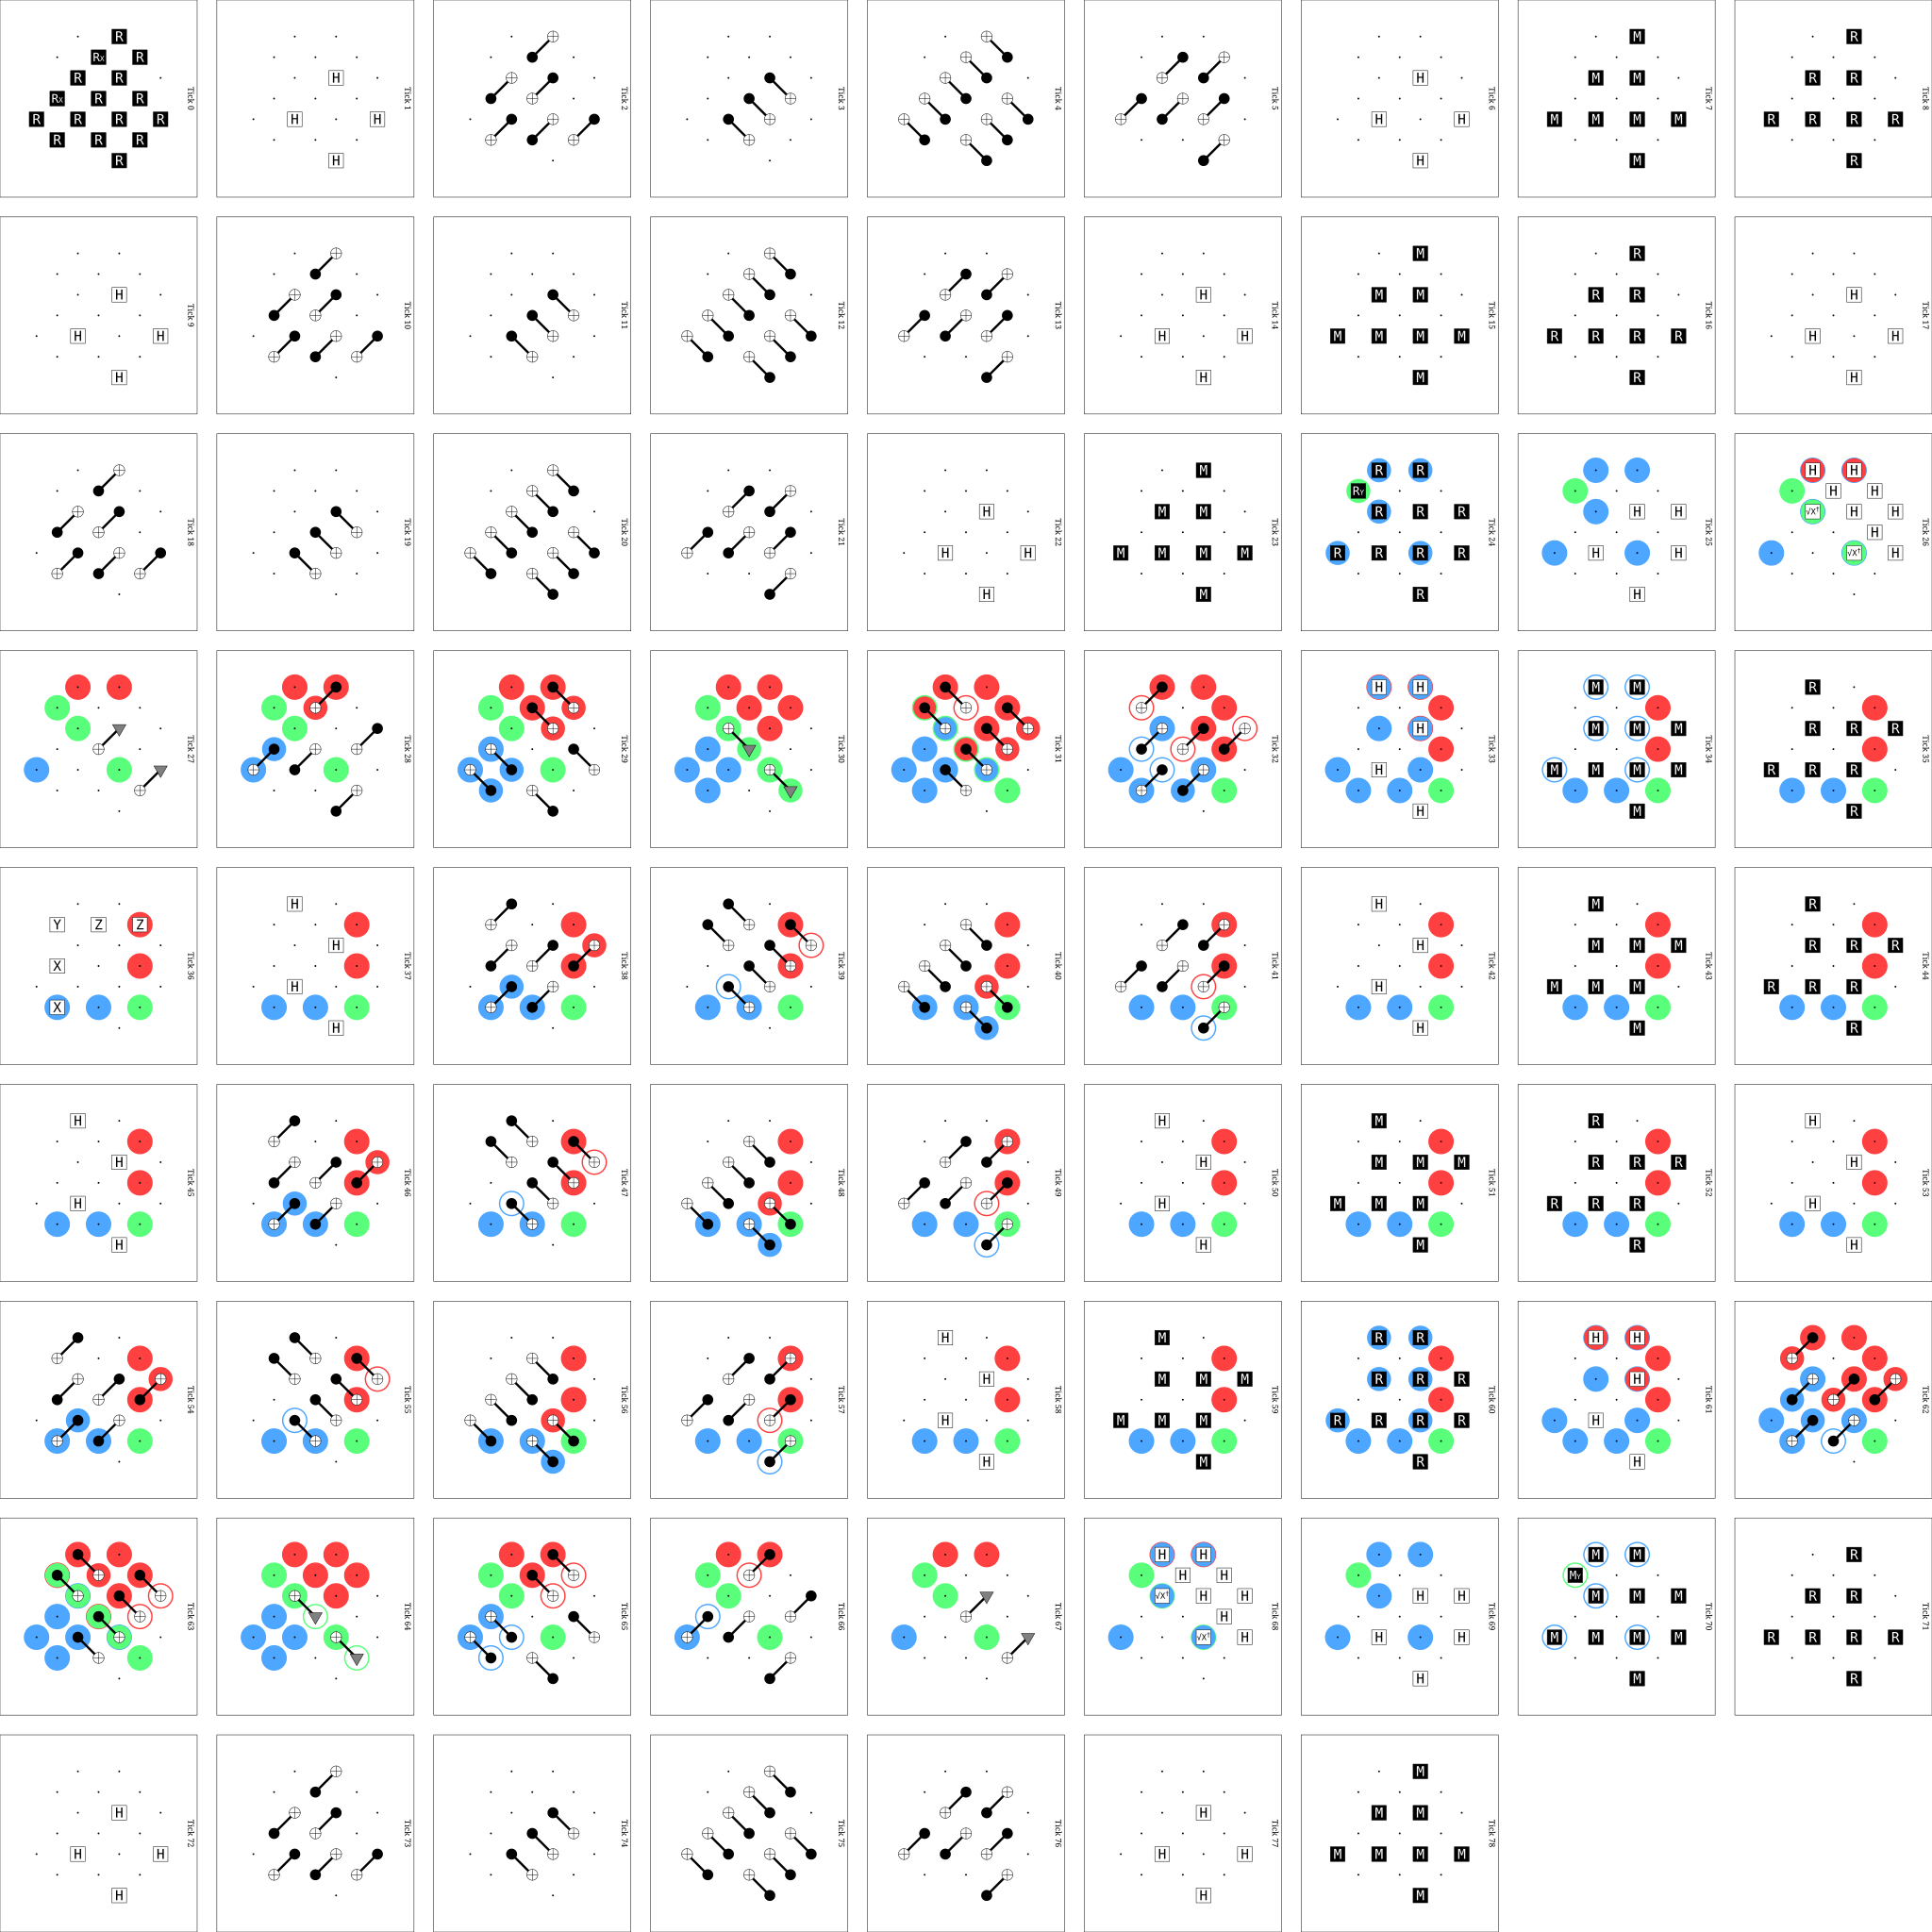

In [3]:
from src.codes.surface_code_rotated.builder import SurfaceBuilder

build = SurfaceBuilder(distance=3, state_init="-i", log_obs="Y")

circuit = build.build_circuit()

circuit.diagram("detslice-with-ops-svg", filter_coords="L0")

In [4]:
from src.codes.lattice_surgery.builder import SurgeryBuilder

**TODO**

- Current Y Observables do not seem to cahnge the measurement outcome when flipped which makes no sense
    - Happens for fault tolerant as well as non fualt tolerant procedure
- Implmented resets on all qubits in non-ft mode but thats total bullshit, makes no sense

In [44]:
test_surgery_builder = SurgeryBuilder(distance=3, control_state_init="Y+", target_state_init="X+",
                                      control_measure_basis="Y", target_measure_basis="I")

test_surgery_circuit = test_surgery_builder.build_circuit()
test_measurement_rec = test_surgery_builder.get_logical_meas_rec(observable_index=0)

test_surgery_circuit, test_measurement_rec

(stim.Circuit('''
     QUBIT_COORDS(0, 2) 0
     QUBIT_COORDS(0, 6) 1
     QUBIT_COORDS(0, 10) 2
     QUBIT_COORDS(1, 1) 3
     QUBIT_COORDS(1, 3) 4
     QUBIT_COORDS(1, 5) 5
     QUBIT_COORDS(1, 7) 6
     QUBIT_COORDS(1, 9) 7
     QUBIT_COORDS(1, 11) 8
     QUBIT_COORDS(2, 2) 9
     QUBIT_COORDS(2, 4) 10
     QUBIT_COORDS(2, 6) 11
     QUBIT_COORDS(2, 8) 12
     QUBIT_COORDS(2, 10) 13
     QUBIT_COORDS(3, 1) 14
     QUBIT_COORDS(3, 3) 15
     QUBIT_COORDS(3, 5) 16
     QUBIT_COORDS(3, 7) 17
     QUBIT_COORDS(3, 9) 18
     QUBIT_COORDS(3, 11) 19
     QUBIT_COORDS(4, 0) 20
     QUBIT_COORDS(4, 2) 21
     QUBIT_COORDS(4, 4) 22
     QUBIT_COORDS(4, 6) 23
     QUBIT_COORDS(4, 8) 24
     QUBIT_COORDS(4, 10) 25
     QUBIT_COORDS(4, 12) 26
     QUBIT_COORDS(5, 1) 27
     QUBIT_COORDS(5, 3) 28
     QUBIT_COORDS(5, 5) 29
     QUBIT_COORDS(5, 7) 30
     QUBIT_COORDS(5, 9) 31
     QUBIT_COORDS(5, 11) 32
     QUBIT_COORDS(6, 2) 33
     QUBIT_COORDS(6, 4) 34
     QUBIT_COORDS(6, 6) 35
     QUBIT_CO

In [49]:
import numpy as np

test_surgery_builder = SurgeryBuilder(distance=3, control_state_init="Y+", target_state_init="X+",
                                      control_measure_basis="Y", target_measure_basis="I",
                                      )
test_surgery_circuit = test_surgery_builder.build_circuit()
test_measurement_rec = test_surgery_builder.get_logical_meas_rec(observable_index=0)

sampler = test_surgery_circuit.compile_sampler()
results_samples = sampler.sample(shots=1000)

final_res = 0
for i in test_measurement_rec:
    final_res ^= results_samples[:, i].astype(np.int8)
print(final_res)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 